## 2) Imports

In [1]:
import os
import re
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split

from transformers import (
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    AutoTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator
)

import evaluate

c:\Users\osamg\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)



Using device: cuda


## 4) Dataset Paths

In [3]:
CSV_PATH = r"flickr30k_images/results.csv"

IMAGE_FOLDER = r"flickr30k_images/flickr30k_images"

In [4]:

df = pd.read_csv(
    CSV_PATH,
    sep='|'
)

print(df.head())
print(df.shape)

       image_name  comment_number  \
0  1000092795.jpg               0   
1  1000092795.jpg               1   
2  1000092795.jpg               2   
3  1000092795.jpg               3   
4  1000092795.jpg               4   

                                             comment  
0   Two young guys with shaggy hair look at their...  
1   Two young , White males are outside near many...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  
(158915, 3)


## 6) CSV Preprocessing

In [5]:
# clean column names
df.columns = df.columns.str.strip()

# remove missing captions
df = df.dropna(subset=['comment'])

# remove duplicates
df = df.drop_duplicates()

# reset index
df = df.reset_index(drop=True)

## 7) Text Cleaning

In [6]:

def clean_caption(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['comment'] = df['comment'].apply(clean_caption)


## 8) Remove Invalid Image Paths

In [7]:
df = df[
    df['image_name'].apply(
        lambda x: os.path.exists(
            os.path.join(IMAGE_FOLDER, x)
        )
    )
]

df = df.reset_index(drop=True)

print("Dataset after preprocessing:", df.shape)

Dataset after preprocessing: (158914, 3)


## 9) Train / Validation Split

In [8]:

# smaller subset for faster training
small_df = df.sample(
    10000,
    random_state=42
)

train_df, val_df = train_test_split(
    small_df,
    test_size=0.1,
    random_state=42
)

print("Train Size:", len(train_df))
print("Validation Size:", len(val_df))

Train Size: 9000
Validation Size: 1000


## 10) Load Pretrained ViT + GPT2 Model

In [9]:
import torch

print(torch.__version__)

print(torch.cuda.is_available())



2.6.0+cu124
True


In [10]:

model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(
    model_name,
    ignore_mismatched_sizes=True
)

feature_extractor = ViTImageProcessor.from_pretrained(
    model_name
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model.to(device)

print("Model Loaded Successfully!")



Loading weights: 100%|██████████| 445/445 [00:00<00:00, 22937.44it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Loaded Successfully!


## 11) Configure Generation Parameters

In [11]:
model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

# Modern generation config
model.generation_config.max_length = 40
model.generation_config.num_beams = 8
model.generation_config.early_stopping = True
model.generation_config.length_penalty = 3.0
model.generation_config.no_repeat_ngram_size = 3

## 12) Create Custom Dataset Class

In [12]:
class Flickr30kDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        feature_extractor
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.tokenizer = tokenizer

        self.feature_extractor = feature_extractor

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = os.path.join(
            IMAGE_FOLDER,
            row['image_name']
        )

        caption = row['comment']
        image = Image.open(
            image_path
        ).convert("RGB")

        pixel_values = self.feature_extractor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.tokenizer(
            caption,
            padding="max_length",
            truncation=True,
            max_length=32,
            return_tensors="pt"
        ).input_ids.squeeze()

        labels[
            labels == tokenizer.pad_token_id
        ] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }



## 13) Create Train and Validation Dataset


In [13]:

train_dataset = Flickr30kDataset(
    train_df,
    tokenizer,
    feature_extractor
)

val_dataset = Flickr30kDataset(
    val_df,
    tokenizer,
    feature_extractor
)

## 14) BLEU Evaluation Metric

In [14]:
bleu = evaluate.load("bleu")

## 15) Compute Metrics Function

In [15]:
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    decoded_preds = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True
    )

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    decoded_labels = [
        [label] for label in decoded_labels
    ]

    result = bleu.compute(
        predictions=decoded_preds,
        references=decoded_labels
    )

    return {
        "bleu": result["bleu"]
    }


## 16) Training Arguments

In [16]:
training_args = Seq2SeqTrainingArguments(

    output_dir="./vit_caption_results",

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    predict_with_generate=True,

    # evaluate every fixed number of steps so BLEU appears during training
    eval_strategy="steps",
    eval_steps=50,

    # save at the same frequency as evaluation so load_best_model_at_end works
    save_strategy="steps",
    save_steps=50,

    logging_steps=50,

    learning_rate=2e-5,

    num_train_epochs=3,

    fp16=torch.cuda.is_available(),

    save_total_limit=3,

    remove_unused_columns=False,

    report_to="none",
    
    warmup_steps=100,
    
    weight_decay=0.01,
    
    gradient_accumulation_steps=2,
    
    load_best_model_at_end=True,
    
    metric_for_best_model="bleu",
)

## 17) Trainer

In [17]:
# Ensure tokenizer and feature extractor from earlier loads are used
# If tokenizer has no pad token (GPT-2), set it to eos
try:
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
except NameError:
    # tokenizer not defined earlier — load a compatible tokenizer
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token

# Use previously loaded feature_extractor as processor
processor = feature_extractor

In [18]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

# ensure trainer has access to tokenizer for generation/metrics
try:
    trainer.tokenizer = tokenizer
except NameError:
    pass

# 18) Start Training

In [19]:
trainer.train()

[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


Step,Training Loss,Validation Loss,Bleu
50,6.093788,2.864360,0.050684
100,5.881031,2.816896,0.043525
150,5.689127,2.795856,0.036870
200,5.819612,2.769165,0.036202
250,5.562123,2.759729,0.036304
300,5.665414,2.753969,0.033854
350,5.544512,2.735231,0.033778
400,5.523118,2.728258,0.033857
450,5.621298,2.716001,0.033264
500,5.768444,2.709881,0.033231


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.46it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


TrainOutput(global_step=1689, training_loss=5.206438307369722, metrics={'train_runtime': 9992.7201, 'train_samples_per_second': 2.702, 'train_steps_per_second': 0.169, 'total_flos': 4.872525060243456e+18, 'train_loss': 5.206438307369722, 'epoch': 3.0})

## 19) Save Final Model


In [20]:
model.save_pretrained(
    "vit_gpt2_flickr30k"
)

feature_extractor.save_pretrained(
    "vit_gpt2_flickr30k"
)

tokenizer.save_pretrained(
    "vit_gpt2_flickr30k"
)

print("Model Saved Successfully!")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]

Model Saved Successfully!


## 20) Prediction Function

In [21]:
model.eval()


def predict_caption(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    pixel_values = feature_extractor(
        images=image,
        return_tensors="pt"
    ).pixel_values.to(device)

    output_ids = model.generate(
        pixel_values,
        max_length=40,
        num_beams=8,
        early_stopping=True,
        length_penalty=3.0,
        no_repeat_ngram_size=3
    )

    caption = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return caption

# 21) Test on New Image

In [22]:

test_image = os.path.join(
    IMAGE_FOLDER,
    train_df.iloc[0]['image_name']
)

predicted_caption = predict_caption(
    test_image
)

print("Generated Caption:")
print(predicted_caption)


Generated Caption:
a man in a suit and hat is walking down the street with a hat on 


## 22) Display Image + Caption

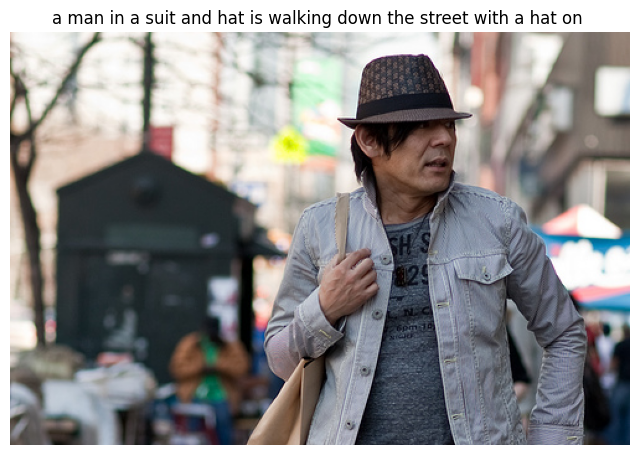

In [23]:
image = Image.open(test_image)

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.axis('off')

plt.title(predicted_caption)

plt.show()

Image: 5897657716.jpg


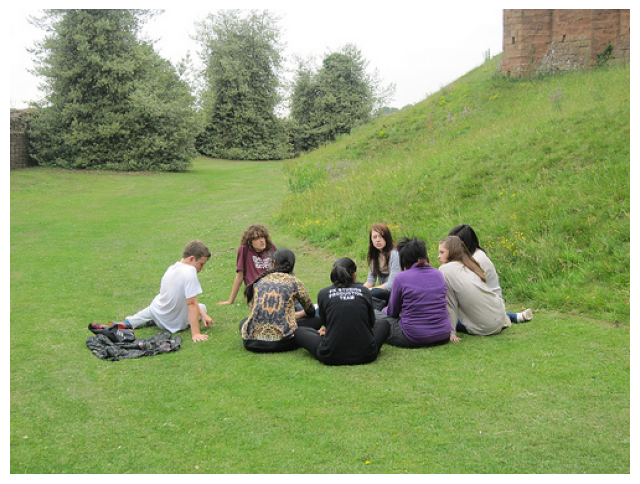

Generated Caption:
a large group of people sitting on top of a lush green hillside next to trees 

Real Caption:
eight young people are sitting in a rough circle in the grass at the bottom of a slight incline with three trees in the background


In [29]:
import os
from PIL import Image
import matplotlib.pyplot as plt

sample = val_df.sample(1).iloc[0]

image_name = sample["image_name"]

test_image = os.path.join(
    "flickr30k_images/flickr30k_images",
    image_name
)

print("Image:", image_name)

# Load image
image = Image.open(test_image).convert("RGB")

# Display image
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

# Preprocessing
pixel_values = feature_extractor(
    images=image,
    return_tensors="pt"
).pixel_values.to(device)

# Caption generation
generated_ids = model.generate(
    pixel_values,
    max_length=40,
    num_beams=8,
    early_stopping=True,
    length_penalty=3.0,
    no_repeat_ngram_size=3
)

generated_caption = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True
)

print("Generated Caption:")
print(generated_caption)

print("\nReal Caption:")
print(sample["comment"])